# Step 5: Forecasting Weekly Store Sales with Drivers

**Goal:** beat the Step 4 baselines by giving a model what planners actually know in advance:
the promotion calendar, holidays, school holidays, planned opening days, store attributes, and
the demand clusters from Step 3.

**Approach:**
1. Build features from SQL Server (only information available before the forecast week).
2. One **LightGBM** model trained across all stores (a "global" model), predicting log sales.
3. **Rolling backtest:** four separate 12-week test windows, including the October–December
   holiday season, each trained only on data before the window.
4. Compare against **seasonal naive** ("same week last year") on the same rows.
5. Explain the model's drivers with **SHAP**, then save the final model for Steps 8 and 10.

**Benchmark from Step 4:** 6.5% WAPE on the 5 sample stores, May–Jul 2015.

In [15]:
import os
import json
import time
import warnings
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid")

FIG_DIR, MODEL_DIR = "../figures", "../models"
for d in (FIG_DIR, MODEL_DIR, "../data/processed"):
    os.makedirs(d, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150)

def wape(actual, pred):
    return np.abs(actual - pred).sum() / actual.sum()

print("LightGBM", lgb.__version__)

drivers = [d for d in pyodbc.drivers() if "ODBC Driver" in d and "SQL Server" in d]
conn = pyodbc.connect(
    f"DRIVER={{{sorted(drivers)[-1]}}};SERVER=localhost;DATABASE=RetailForecast;"
    "Trusted_Connection=yes;TrustServerCertificate=yes;"
)
print("Connected")

LightGBM 4.7.0
Connected


## 1. Load weekly data

Full weeks only (partial weeks from Step 1 excluded) and weeks with sales, joined to store
attributes and the Step 3 clusters.

In [16]:
df = pd.read_sql("""
    SELECT w.Store, w.WeekStart, w.WeeklySales, w.OpenDays, w.PromoDays,
           w.StateHolidayDays, w.SchoolHolidayDays,
           s.StoreType, s.Assortment, s.CompetitionDistance,
           s.CompetitionOpenSinceMonth, s.CompetitionOpenSinceYear,
           CAST(s.Promo2 AS INT) AS Promo2, s.Promo2SinceWeek, s.Promo2SinceYear, s.PromoInterval,
           c.Cluster
    FROM weekly_store_sales w
    JOIN stores s ON s.Store = w.Store
    JOIN store_clusters c ON c.Store = w.Store
    WHERE w.DaysInData = 7 AND w.WeeklySales > 0
""", conn, parse_dates=["WeekStart"])

df = df.sort_values(["Store", "WeekStart"]).reset_index(drop=True)
print(f"Rows: {len(df):,}   Stores: {df['Store'].nunique():,}   "
      f"Weeks: {df['WeekStart'].min().date()} to {df['WeekStart'].max().date()}")

Rows: 143,224   Stores: 1,115   Weeks: 2013-01-07 to 2015-07-20


## 2. Feature engineering

Every feature is known **before** the week being forecast:

| Group | Features | Source |
|---|---|---|
| Calendar | week of year, month, year | Date |
| Planned drivers | promo days, state holiday days, school holiday days, open days | Chain calendar |
| Loyalty promo | whether the store's ongoing Promo2 runs that month | Store table |
| Competition | log distance, no-competitor flag, months since competitor opened | Store table (Step 1 rules) |
| Store profile | store type, assortment, demand cluster | Store table, Step 3 |
| History | sales in the same week last year (lag 52) | Past sales (52 weeks > 12-week horizon, so no leakage) |
| Store level | store's average log sales in the training period | Computed per backtest window |

In [17]:
# Calendar
iso = df["WeekStart"].dt.isocalendar()
df["WeekOfYear"] = iso["week"].astype(int)
df["Month"] = df["WeekStart"].dt.month
df["Year"] = df["WeekStart"].dt.year

# Competition (Step 1 rules: missing distance = no nearby competitor; missing open date = open throughout)
df["NoCompetitor"] = df["CompetitionDistance"].isna().astype(int)
df["LogCompDistance"] = np.log1p(df["CompetitionDistance"].fillna(100_000))
comp_open = pd.to_datetime(dict(year=df["CompetitionOpenSinceYear"].fillna(1900),
                                month=df["CompetitionOpenSinceMonth"].fillna(1), day=1))
df["CompMonthsOpen"] = ((df["WeekStart"] - comp_open).dt.days / 30.4).clip(lower=0).clip(upper=120)

# Promo2: ongoing loyalty promotion, active from its start week in the listed months
MONTH_ABBR = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sept", "Oct", "Nov", "Dec"]

def promo2_start(row):
    try:
        return pd.Timestamp.fromisocalendar(int(row.Promo2SinceYear), int(row.Promo2SinceWeek), 1)
    except (ValueError, TypeError):
        return pd.NaT

starts = (df[df["Promo2"] == 1].drop_duplicates("Store").set_index("Store")
          .apply(promo2_start, axis=1))
df["Promo2Start"] = df["Store"].map(starts)
in_interval = [MONTH_ABBR[m - 1] in str(pi).split(",") for m, pi in zip(df["Month"], df["PromoInterval"])]
df["Promo2Active"] = ((df["Promo2"] == 1) & (df["WeekStart"] >= df["Promo2Start"])
                      & np.array(in_interval)).astype(int)

# Same week last year (364 days = 52 weeks, same weekday)
lag = df[["Store", "WeekStart", "WeeklySales"]].copy()
lag["WeekStart"] = lag["WeekStart"] + pd.Timedelta(days=364)
df = df.merge(lag.rename(columns={"WeeklySales": "SalesLag52"}), on=["Store", "WeekStart"], how="left")
df["LogSalesLag52"] = np.log1p(df["SalesLag52"])

# Categoricals and target
for col in ["StoreType", "Assortment", "Cluster"]:
    df[col] = df[col].astype(str).astype("category")
df["y"] = np.log1p(df["WeeklySales"])

FEATURES = ["WeekOfYear", "Month", "Year", "PromoDays", "StateHolidayDays", "SchoolHolidayDays",
            "OpenDays", "Promo2Active", "NoCompetitor", "LogCompDistance", "CompMonthsOpen",
            "StoreType", "Assortment", "Cluster", "LogSalesLag52", "StoreLevel"]

print(f"Features: {len(FEATURES)}")
print(f"Rows with a lag-52 value: {df['SalesLag52'].notna().mean():.0%}")
df[["Promo2Active", "NoCompetitor", "CompMonthsOpen"]].describe().round(2)

Features: 16
Rows with a lag-52 value: 59%


,Promo2Active,NoCompetitor,CompMonthsOpen
count,143224.00,143224.00,143224.00
mean,0.15,0.00,75.86
std,0.35,0.05,46.30
min,0.00,0.00,0.00
25%,0.00,0.00,29.57
50%,0.00,0.00,91.55
75%,0.00,0.00,120.00
max,1.00,1.00,120.00


## 3. Rolling backtest

Four 12-week windows. For each: train on every week **before** the window, forecast all 12 weeks
at once, then score. W4 matches the Step 4 Excel holdout exactly.

In [18]:
WINDOWS = {
    "W1 Spring 2014":  "2014-05-05",
    "W2 Holiday 2014": "2014-10-06",   # covers the Christmas peak
    "W3 Early 2015":   "2015-02-02",
    "W4 Summer 2015":  "2015-05-04",   # same as the Excel holdout
}
HORIZON = 12

PARAMS = dict(n_estimators=800, learning_rate=0.05, num_leaves=63, min_child_samples=50,
              subsample=0.8, subsample_freq=1, colsample_bytree=0.8, random_state=42, verbose=-1)

def add_store_level(train, other):
    level = train.groupby("Store")["y"].mean()
    other = other.copy()
    other["StoreLevel"] = other["Store"].map(level)
    return other

results = []
for name, start in WINDOWS.items():
    t0 = time.time()
    start = pd.Timestamp(start)
    end = start + pd.Timedelta(weeks=HORIZON)
    train = df[df["WeekStart"] < start]
    test = df[(df["WeekStart"] >= start) & (df["WeekStart"] < end)]

    train = add_store_level(train, train)
    test = add_store_level(train, test)

    model = lgb.LGBMRegressor(**PARAMS).fit(train[FEATURES], train["y"])
    test = test.assign(Window=name,
                       Pred_LGBM=np.expm1(model.predict(test[FEATURES])),
                       Pred_Naive=test["SalesLag52"])
    results.append(test)
    print(f"{name}: trained on {len(train):,} rows, tested on {len(test):,} rows ({time.time() - t0:.0f}s)")

bt = pd.concat(results, ignore_index=True)

W1 Spring 2014: trained on 76,786 rows, tested on 12,634 rows (3s)
W2 Holiday 2014: trained on 98,750 rows, tested on 11,220 rows (3s)
W3 Early 2015: trained on 115,363 rows, tested on 13,372 rows (3s)
W4 Summer 2015: trained on 129,850 rows, tested on 13,374 rows (3s)


## 4. Results

Both models are scored on the **same rows**: store-weeks where last year's value exists, so
the naive forecast is possible (this excludes weeks affected by the 180-store gap).

In [19]:
scored = bt[bt["Pred_Naive"].notna()]

summary = (scored.groupby("Window", sort=False)
           .apply(lambda g: pd.Series({
               "Store-weeks": len(g),
               "Naive WAPE": wape(g["WeeklySales"], g["Pred_Naive"]),
               "LightGBM WAPE": wape(g["WeeklySales"], g["Pred_LGBM"]),
           })))
summary.loc["All windows"] = [len(scored), wape(scored["WeeklySales"], scored["Pred_Naive"]),
                              wape(scored["WeeklySales"], scored["Pred_LGBM"])]
summary["Error reduction"] = 1 - summary["LightGBM WAPE"] / summary["Naive WAPE"]
summary["Store-weeks"] = summary["Store-weeks"].astype(int)

print(f"Rows scored: {len(scored):,} of {len(bt):,} "
      f"({len(scored) / len(bt):.0%}; the rest have no same-week-last-year value)")
summary.style.format({"Naive WAPE": "{:.1%}", "LightGBM WAPE": "{:.1%}", "Error reduction": "{:.0%}"})

Rows scored: 49,819 of 50,600 (98%; the rest have no same-week-last-year value)


,Store-weeks,Naive WAPE,LightGBM WAPE,Error reduction
Window,,,,
W1 Spring 2014,12610,17.0%,6.5%,62%
W2 Holiday 2014,11220,11.4%,6.5%,43%
W3 Early 2015,13360,8.5%,6.6%,22%
W4 Summer 2015,12629,8.0%,5.5%,31%
All windows,49819,11.2%,6.3%,44%


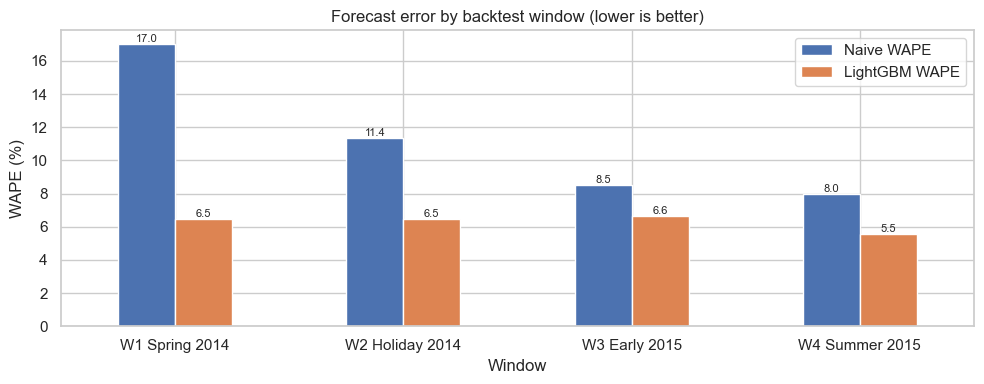

In [20]:
plot = summary.drop("All windows")[["Naive WAPE", "LightGBM WAPE"]] * 100
ax = plot.plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_ylabel("WAPE (%)")
ax.set_title("Forecast error by backtest window (lower is better)")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=8)
save("10_backtest_wape")
plt.show()

In [21]:
lagp = (df[["Store", "WeekStart", "PromoDays"]]
        .assign(WeekStart=lambda d: d["WeekStart"] + pd.Timedelta(days=364))
        .rename(columns={"PromoDays": "PromoLag52"}))
chk = bt.merge(lagp, on=["Store", "WeekStart"])
(chk["PromoDays"] == chk["PromoLag52"]).groupby(chk["Window"]).mean()

Window
W1 Spring 2014     0.647581
W2 Holiday 2014    0.750000
W3 Early 2015      1.000000
W4 Summer 2015     1.000000
dtype: float64

**Finding:**  Across four 12-week backtest windows (49,819 store-weeks), LightGBM reduced forecast error from 11.2% to 6.3% WAPE, a 44% reduction versus seasonal naive. The model stayed between 5.5% and 6.6% in every window, including the Oct–Dec holiday season (naive 11.4%), while the naive forecast ranged from 8.0% to 17.0%. The naive forecast failed when the promotion calendar shifted: only 65% of weeks in spring 2014 had the same promo status as the prior year (naive WAPE 17.0%), versus 100% in 2015 (8.0–8.5%). LightGBM, which uses the actual promo calendar, stayed stable, and still cut error by 22–31% even in the fully aligned windows.

In [22]:
by_cluster = (scored.groupby("Cluster", observed=True)
              .apply(lambda g: pd.Series({
                  "Store-weeks": len(g),
                  "Naive WAPE": wape(g["WeeklySales"], g["Pred_Naive"]),
                  "LightGBM WAPE": wape(g["WeeklySales"], g["Pred_LGBM"]),
              })))
by_cluster["Error reduction"] = 1 - by_cluster["LightGBM WAPE"] / by_cluster["Naive WAPE"]
by_cluster["Store-weeks"] = by_cluster["Store-weeks"].astype(int)
by_cluster.style.format({"Naive WAPE": "{:.1%}", "LightGBM WAPE": "{:.1%}", "Error reduction": "{:.0%}"})

,Store-weeks,Naive WAPE,LightGBM WAPE,Error reduction
Cluster,,,,
1,19182,11.2%,5.9%,48%
2,384,9.9%,8.9%,10%
3,7746,11.6%,7.0%,39%
4,788,9.0%,6.1%,32%
5,21719,11.2%,6.3%,43%


**Finding:**The model's gain tracks each cluster's promotion sensitivity: the most promo-sensitive cluster (weekday-focused, +43% promo lift) improved most, from 11.2% to 5.9% WAPE (48% reduction), while the least promo-sensitive clusters gained least. The summer/tourist cluster remains hardest (8.9% WAPE, 10% reduction): with only 8 stores (<1% of training data), the global model underweights its summer seasonality. A dedicated model or a store-level seasonality feature is a possible next improvement. Christmas-driven stores are second hardest (7.0%) because the size of the December peak varies from year to year.

### Comparison with the Excel baselines (Step 4)

Same 5 stores, same 12 weeks (W4). Excel results: seasonal naive 6.6% WAPE, FORECAST.ETS 6.5%.

In [23]:
sample = pd.read_csv("../data/processed/sample_stores.csv")
w4 = bt[(bt["Window"] == "W4 Summer 2015") & bt["Store"].isin(sample["Store"])]

excel_cmp = w4.groupby("Store").apply(lambda g: pd.Series({
    "Naive WAPE": wape(g["WeeklySales"], g["Pred_Naive"]),
    "LightGBM WAPE": wape(g["WeeklySales"], g["Pred_LGBM"]),
}))
excel_cmp["Excel ETS WAPE"] = excel_cmp.index.map({314: .086, 299: .080, 763: .055, 259: .044, 640: .059})
excel_cmp.loc["Average"] = excel_cmp.mean()
excel_cmp.style.format("{:.1%}")

,Naive WAPE,LightGBM WAPE,Excel ETS WAPE
Store,,,
259,7.1%,4.3%,4.4%
299,8.0%,9.1%,8.0%
314,6.8%,3.8%,8.6%
640,7.3%,5.4%,5.9%
763,3.9%,1.8%,5.5%
Average,6.6%,4.9%,6.5%


**Finding:** On the same 5 stores and 12 weeks as the Step 4 Excel holdout, the Python seasonal naive reproduces the Excel results exactly (6.6% average WAPE), confirming both pipelines. LightGBM averages 4.9% WAPE versus 6.5% for Excel's FORECAST.ETS, about 25% lower, and wins on 4 of 5 stores (e.g., store 314: 8.6% to 3.8%). The exception is the summer/tourist store 299 (9.1% vs. 8.0%), consistent with the cluster-level finding that the global model underweights summer seasonality.

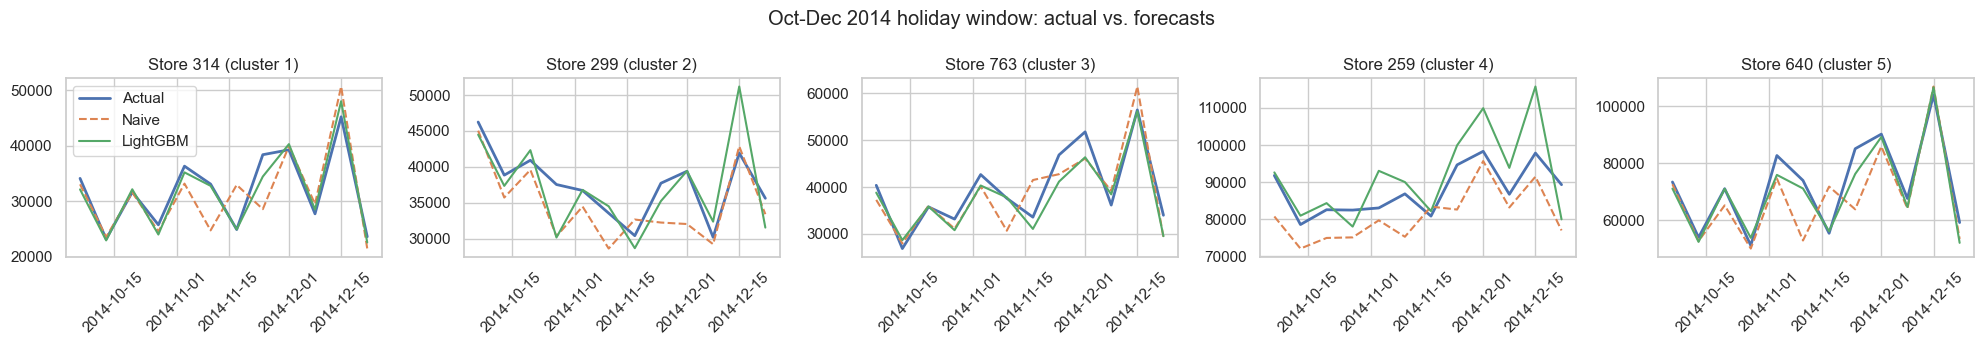

In [24]:
# Holiday window up close: actual vs. forecasts for the 5 sample stores
w2 = bt[(bt["Window"] == "W2 Holiday 2014") & bt["Store"].isin(sample["Store"])]
stores_in_w2 = [s for s in sample["Store"] if s in set(w2["Store"])]
assert stores_in_w2, "No sample stores in the holiday window"

fig, axes = plt.subplots(1, len(stores_in_w2), figsize=(4 * len(stores_in_w2), 3.5), sharex=True)
axes = np.atleast_1d(axes)
for ax, store in zip(axes, stores_in_w2):
    g = w2[w2["Store"] == store].set_index("WeekStart")
    ax.plot(g.index, g["WeeklySales"], label="Actual", lw=2)
    ax.plot(g.index, g["Pred_Naive"], label="Naive", ls="--")
    ax.plot(g.index, g["Pred_LGBM"], label="LightGBM")
    ax.set_title(f"Store {store} (cluster {g['Cluster'].iloc[0]})")
    ax.tick_params(axis="x", rotation=45)
axes[0].legend()
fig.suptitle("Oct-Dec 2014 holiday window: actual vs. forecasts")
save("11_holiday_window_samples")
plt.show()

**Finding:** In the Oct–Dec 2014 window, LightGBM tracks the actuals closely for stores in clusters 1, 3 and 5, including the mid-December peak, while the naive forecast runs out of phase with the promotion cycle. For stores with weaker December seasonality (summer/tourist 299 and Sunday-trading 259), the model overshoots the Christmas peak by roughly 20%, applying the chain-wide holiday lift. Adding each store's own seasonal profile from Step 3 as a feature is a clear next improvement.

## 5. What drives the forecast? (SHAP)

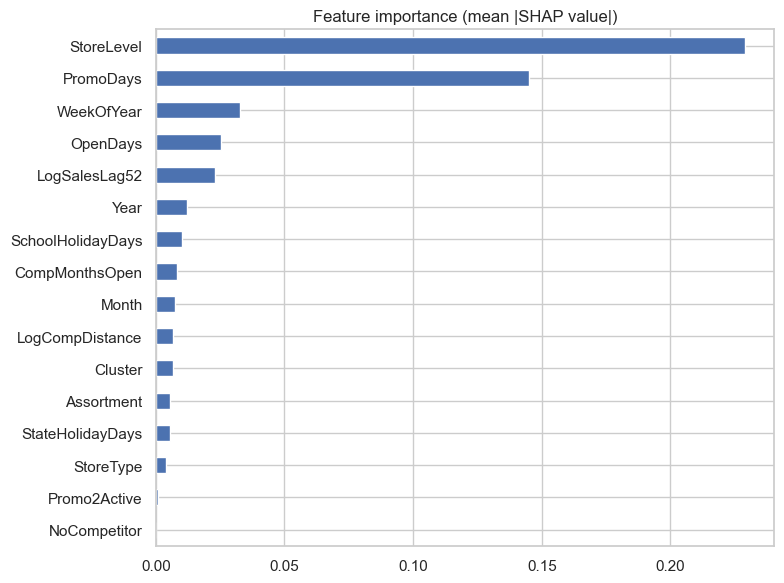

In [25]:
# Final model: trained on all data, used for explanations, inventory (Step 8) and the app (Step 10)
full = add_store_level(df, df)
final_model = lgb.LGBMRegressor(**PARAMS).fit(full[FEATURES], full["y"])

X_explain = full[FEATURES].sample(5000, random_state=42)
try:
    import shap
    shap_values = shap.TreeExplainer(final_model).shap_values(X_explain)
    importance = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values()
    method = "mean |SHAP value|"
except Exception as e:   # shap missing or incompatible with this Python version
    print(f"SHAP unavailable ({type(e).__name__}); using LightGBM gain importance instead")
    importance = pd.Series(final_model.booster_.feature_importance("gain"), index=FEATURES).sort_values()
    method = "LightGBM gain"

ax = importance.plot(kind="barh", figsize=(8, 6))
ax.set_title(f"Feature importance ({method})")
save("12_feature_importance")
plt.show()

**Finding:** After store size (StoreLevel), the promotion calendar is by far the strongest driver of weekly sales, moving forecasts by roughly 15% on average (mean |SHAP| of 0.145 in log sales), followed by seasonality (week of year) and planned open days. Last year's sales add comparatively little, which is why the driver-based model outperforms "same week last year." Competition features contribute little, consistent with EDA (r = −0.10), and the ongoing loyalty promotion (Promo2) has almost no measurable effect on weekly sales.

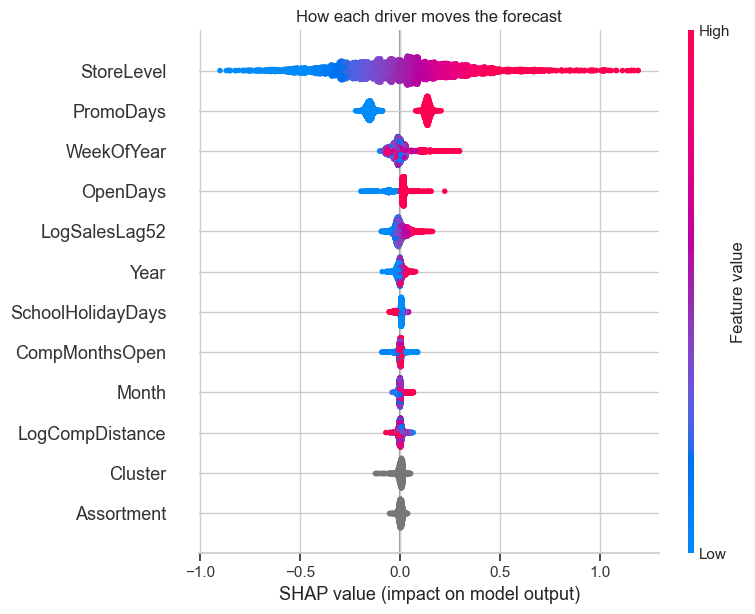

In [26]:
# Direction of each driver's effect (requires shap)
if "shap_values" in globals():
    shap.summary_plot(shap_values, X_explain, show=False, max_display=12)
    plt.title("How each driver moves the forecast")
    save("13_shap_summary")
    plt.show()

**Finding:** **Finding:** The model learned effect sizes that match the EDA. Promotion weeks raise forecasts by about 35% relative to non-promo weeks (EDA: +34%), late-year weeks by up to about 35% (EDA pre-Christmas: +36%), and weeks with holiday closures lose up to about 20%. Later years push forecasts slightly up (mild growth), while school holidays and competitor distance have small, mixed effects. This agreement with the hand-measured EDA results suggests the model captures genuine business drivers rather than noise.

## 6. Save the model and backtest results

In [27]:
final_model.booster_.save_model(f"{MODEL_DIR}/lgbm_weekly.txt")

full.groupby("Store")["y"].mean().rename("StoreLevel").to_csv(f"{MODEL_DIR}/store_level.csv")

config = {
    "features": FEATURES,
    "target": "log1p(WeeklySales)",
    "categorical": {c: list(df[c].cat.categories) for c in ["StoreType", "Assortment", "Cluster"]},
    "params": PARAMS,
    "trained_through": str(df["WeekStart"].max().date()),
    "backtest_wape": {k: round(float(v), 4) for k, v in summary["LightGBM WAPE"].items()},
}
with open(f"{MODEL_DIR}/model_config.json", "w") as f:
    json.dump(config, f, indent=2)

# Backtest predictions feed the safety-stock calculation in Step 8
bt[["Window", "Store", "WeekStart", "Cluster", "WeeklySales", "Pred_Naive", "Pred_LGBM"]] \
    .to_csv("../data/processed/backtest_predictions.csv", index=False)
print("Saved model, config, store levels, and backtest predictions")

Saved model, config, store levels, and backtest predictions


## Summary of findings

- **Headline:** across a 4-window rolling backtest (49,819 store-weeks), LightGBM reduced forecast error from 11.2% to 6.3% WAPE, a 44% reduction versus seasonal naive, and stayed between 5.5% and 6.6% in every window, including the holiday season.
- **Why the baseline fails:** "same week last year" breaks when the promotion calendar shifts (65% alignment in spring 2014 gave 17.0% WAPE); the model uses the actual promo calendar and stays stable.
- **Beats the Excel benchmark:** 4.9% vs. 6.5% WAPE (FORECAST.ETS) on the same 5 stores and 12 weeks, with the Python naive reproducing the Excel naive exactly.
- **Drivers:** after store size, promotions dominate (≈ +35%), followed by Christmas seasonality (≈ +35%) and open days, matching the EDA estimates.
- **Limitation and next step:** the summer/tourist cluster remains hardest (8.9% WAPE), and the model overshoots Christmas for stores with weaker December peaks; store-level seasonality features are the clearest improvement.

In [28]:
conn.close()